<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
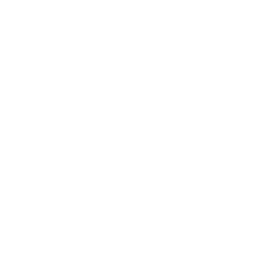
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Utilizzo delle Risorse per Reparto Ospedaliero — Grafico a Barre Orizzontali</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Sanità / Operazioni Ospedaliere &nbsp;|&nbsp; Marzo 2026</p>
</div>
</div>
</div>

## Riepilogo Esecutivo

Questo esempio utilizza i grafici a barre orizzontali (HBAR) di **PROC GCHART** per profilare le ore di personale in sei reparti clinici per il Q1 2026. Un registro sintetico del personale di **90 record turno** (15 per reparto) alimenta tre viste: un grafico a barre delle ore totali ordinato, la durata media del turno per reparto, e HBAR raggruppati che suddividono ogni reparto per categoria di risorsa e per turno. `SUMVAR=` accumula le ore di lavoro effettive invece di contare i record, `TYPE=SUM`/`TYPE=MEAN` cambiano la statistica di risposta, `DESCENDING` ordina i reparti in modo decrescente, e `GROUP=` disegna barre raggruppate adiacenti per una seconda dimensione.

L'output supporta la revisione trimestrale dell'efficienza operativa: evidenzia quali reparti consumano più personale, quali hanno i turni più lunghi, e come lo schema di personale giorno/sera/notte differisca tra le unità ad assistenza continua e i servizi orientati al giorno.

## Fonti dei Dati

| Fonte | Descrizione | Record |
|--------|-------------|--------|
| WORK.STAFFING_LOG | Record dei turni di lavoro individuali con le ore lavorate | 90 |
| WORK.DEPT_SUMMARY | Totali a livello di reparto e durata media del turno | 6 |

---

In [1]:
/* --------------------------------------------------------
   Genera un registro sintetico delle ore di personale ospedaliero.
   Q1 2026: 6 reparti clinici, 4 categorie di risorse,
   3 turni. Dimensionato a 15 record turno per reparto
   (90 totali) cosi l'intero organico dei reparti resta visibile.
   -------------------------------------------------------- */
DATI work.staffing_log;
    CHIAMARE streaminit(20260601);
    LUNGHEZZA department $20 resource_type $14 shift $6;

    /* mix delle categorie di risorse (personale a prevalenza infermieristica) */
    VETTORE res[4]  $14 _temporary_
        ('Infermieri' 'Medici' 'Sanitari' 'Supporto');
    VETTORE resw[4] _temporary_ (0.50 0.20 0.20 0.10);

    /* mix turni di base, spostato verso la Notte per le unita 24/7 */
    VETTORE shfw[3] _temporary_ (0.45 0.30 0.25);
    VETTORE nightlift[6] _temporary_
        (0.18 0.00 0.22 -0.05 -0.05 0.05);

    FARE di = 1 FINO_A 6;
        /* assegnazione diretta if/else (non array _temporary_) perche
           "Maternita" contiene un carattere accentato non-ASCII */
        SE_COND di = 1 ALLORA department = 'Pronto Soccorso';
        ALTRIMENTI SE_COND di = 2 ALLORA department = 'Chirurgia';
        ALTRIMENTI SE_COND di = 3 ALLORA department = 'Terapia Intensiva';
        ALTRIMENTI SE_COND di = 4 ALLORA department = 'Pediatria';
        ALTRIMENTI SE_COND di = 5 ALLORA department = 'Oncologia';
        ALTRIMENTI department = 'Maternità';
        FARE rec = 1 FINO_A 15;

            /* tipo di risorsa tramite estrazione pesata */
            u = rand('uniform'); cum = 0;
            FARE r = 1 FINO_A 4;
                cum + resw[r];
                SE_COND u <= cum ALLORA FARE;
                    resource_type = res[r];
                    USCIRE;
                FINE;
            FINE;

            /* turno tramite l'inclinazione notturna specifica del reparto */
            w1 = shfw[1] - nightlift[di] / 2;
            w2 = shfw[2] - nightlift[di] / 2;
            u = rand('uniform');
            SE_COND u <= w1 ALLORA shift = 'Giorno';
            ALTRIMENTI SE_COND u <= w1 + w2 ALLORA shift = 'Sera';
            ALTRIMENTI shift = 'Notte';

            /* ore: medici e chirurgia fanno turni piu lunghi */
            base_hrs = 8;
            SE_COND resource_type = 'Medici' ALLORA base_hrs = base_hrs + 1.5;
            SE_COND department = 'Chirurgia'      ALLORA base_hrs = base_hrs + 1.0;
            hours_worked = round(base_hrs + rand('normal', 0, 0.8), 0.25);
            SE_COND hours_worked < 4 ALLORA hours_worked = 4;

            USCITA;
        FINE;
    FINE;
    MANTENERE department resource_type shift hours_worked;
ESEGUIRE;


NOTE: DATA work.staffing_log


NOTE: Wrote work.staffing_log (90 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


In [2]:
/* --------------------------------------------------------
   Totali di reparto e durata media del turno,
   classificati per ore totali di lavoro.
   -------------------------------------------------------- */
PROCEDURA SQL;
    CREARE TABELLA work.dept_summary AS
    SELEZIONARE department,
           sum(hours_worked)  AS total_hours   FORMATO=8.2,
           count(*)           AS shift_count,
           mean(hours_worked) AS avg_shift_hrs  FORMATO=6.2
    FROM work.staffing_log
    GROUP PER department
    ORDER PER total_hours DESC;
QUIT;

PROCEDURA STAMPARE DATI=work.dept_summary noobs ETICHETTA;
    ETICHETTA total_hours   = 'Ore Totali'
          shift_count   = 'Turni'
          avg_shift_hrs = 'Turno Medio (ore)';
    TITOLO 'Riepilogo Ore Lavorate per Reparto - Q1 2026';
ESEGUIRE;
TITOLO;

                                      Riepilogo Ore Lavorate per Reparto - Q1 2026                                      

       department  Ore Totali  Turni  Turno Medio (ore)
Chirurgia              136.25     15               9.08
Terapia Intensiva      128.50     15               8.57
Maternità              127.75     15               8.52
Pediatria              124.75     15               8.32
Oncologia              123.75     15               8.25
Pronto Soccorso        119.25     15               7.95




NOTE: PROC SQL 

NOTE: Table work.dept_summary created.
NOTE: PROC SQL statement used.
NOTE: PROC PRINT data=work.dept_summary

NOTE: PROC PRINT completed: 6 observations printed, 4 variables


---

                                                Ore Lavorate per Reparto                                                

                                                  The MEANS Procedure

                                     Analysis Variable : hours_worked Ore Lavorate

        Reparto                      Sum           Mean          N Obs
        --------------------------------------------------------------
        Chirurgia                 136.25           9.08             15
        Maternità                 127.75           8.52             15
        Oncologia                 123.75           8.25             15
        Pediatria                 124.75           8.32             15
        Pronto Soccorso           119.25           7.95             15
        Terapia Intensiva         128.50           8.57             15
        --------------------------------------------------------------

                                          Distribuzione dei Turni per Reparto      


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_department_shift.spec.json
NOTE: PROC FREQ statement used.


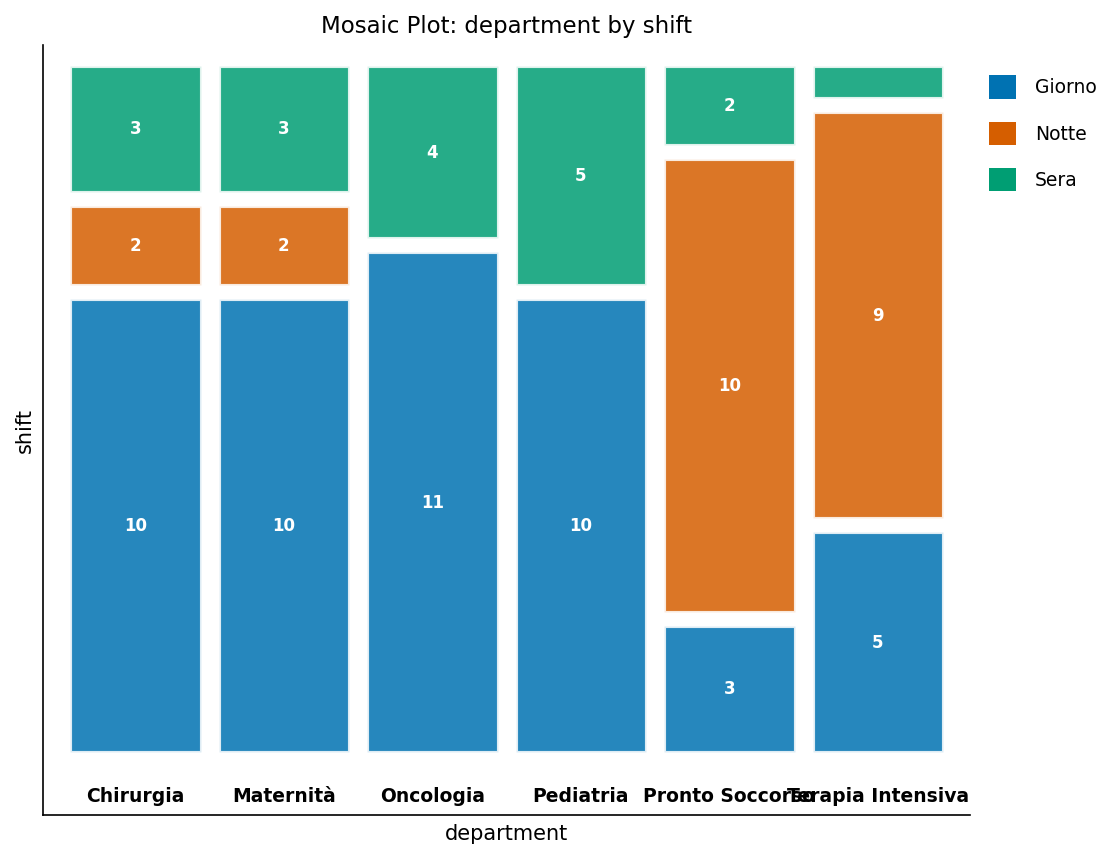

In [3]:
/* --------------------------------------------------------
   Tabelle di base: ore lavorate per reparto, e la
   distribuzione dei turni giorno / sera / notte per reparto.
   -------------------------------------------------------- */
PROCEDURA MEDIE DATI=work.staffing_log sum mean n maxdec=2;
    CLASSE department;
    VARIABILE hours_worked;
    ETICHETTA department='Reparto' hours_worked='Ore Lavorate';
    TITOLO 'Ore Lavorate per Reparto';
ESEGUIRE;

PROCEDURA FREQUENZE DATI=work.staffing_log;
    TABLES department * shift / norow nocol nopercent;
    ETICHETTA department='Reparto' shift='Turno';
    TITOLO 'Distribuzione dei Turni per Reparto';
ESEGUIRE;
TITOLO;

---


NOTE: PROC GCHART data=work.staffing_log

NOTE: ODS plot written: gchart_hbar.spec.json


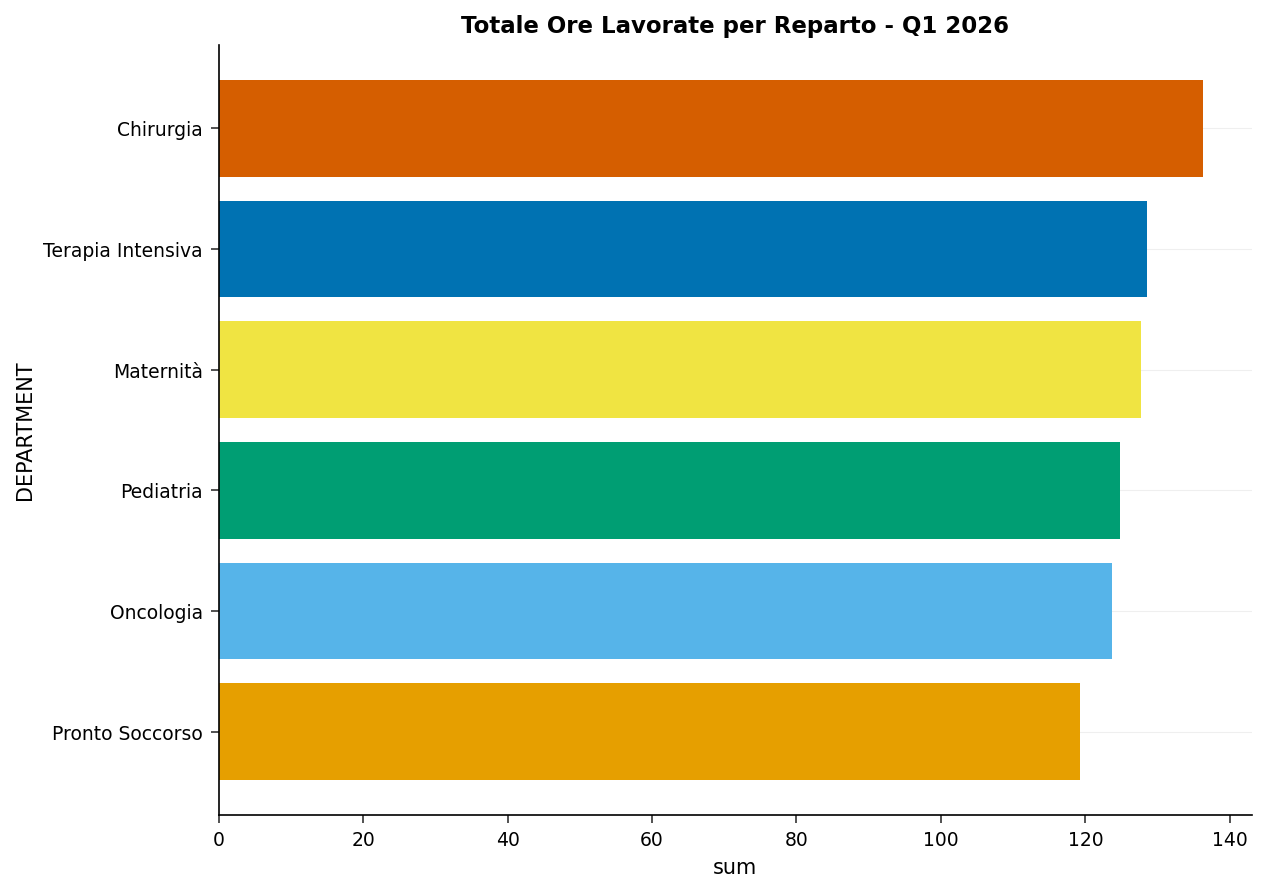

In [4]:
/* --------------------------------------------------------
   HBAR panoramico: ore totali di lavoro per reparto.
   SUMVAR= somma le ore; DESCENDING ordina le barre in modo decrescente.
   -------------------------------------------------------- */
PROCEDURA GCHART DATI=work.staffing_log;
    HBAR department / SUMVAR=hours_worked
                      type=sum
                      DISCENDENTE;
    ETICHETTA department='Reparto' hours_worked='Ore Lavorate';
    TITOLO 'Totale Ore Lavorate per Reparto - Q1 2026';
ESEGUIRE;
QUIT;
TITOLO;

### Suddivisione di ogni reparto per categoria di risorsa

`GROUP=` disegna un cluster di barre orizzontali adiacenti per ogni reparto, una barra per categoria di risorsa. Poiché `SUMVAR=hours_worked` è in vigore, ogni barra misura le ore di lavoro accumulate invece di un conteggio di record, così il grafico mostra come le ore di personale infermieristico, medico, sanitario ausiliario e di supporto si confrontano *all'interno* di ogni reparto.

In [5]:
/* --------------------------------------------------------
   Istruzioni PATTERN: tavolozza coordinata di 4 colori,
   un pattern per ogni sottogruppo di categoria di risorsa
   -------------------------------------------------------- */
pattern1 VALUE=solid color=cx2C5F8A;   /* Infermieri - blu intenso */
pattern2 VALUE=solid color=cx28A745;   /* Medici - verde           */
pattern3 VALUE=solid color=cxE8650A;   /* Sanitari - ambra         */
pattern4 VALUE=solid color=cx6C757D;   /* Supporto - grigio        */

                                   Ore Lavorate per Reparto e Categoria di Personale                                    


Fonte: Sistema di Gestione del Personale | Periodo di riferimento: Gen-Mar 2026



NOTE: Option TITLE changed to Ore Lavorate per Reparto e Categoria di Personale.
NOTE: Option FOOTNOTE changed to Fonte: Sistema di Gestione del Personale | Periodo di riferimento: Gen-Mar 2026.
NOTE: PROC GCHART data=work.staffing_log

NOTE: ODS plot written: gchart_hbar.spec.json


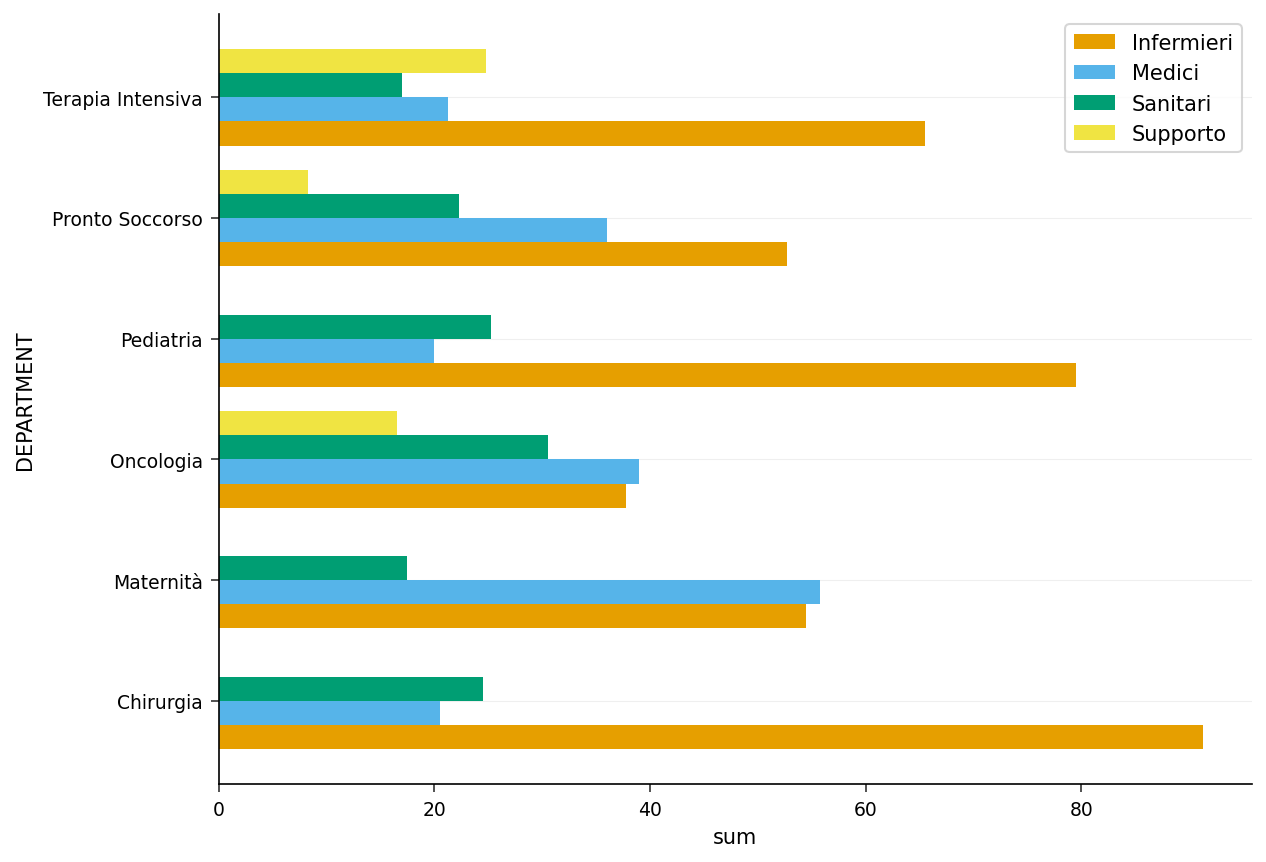

In [6]:
/* --------------------------------------------------------
   HBAR raggruppato per categoria di risorsa (GROUP=).
   Ogni reparto diventa un cluster di barre -- una per
   categoria di risorsa -- misurata in ore di lavoro accumulate.
   -------------------------------------------------------- */
TITOLO 'Ore Lavorate per Reparto e Categoria di Personale';
footnote JUSTIFY=LEFT
    'Fonte: Sistema di Gestione del Personale | Periodo di riferimento: Gen-Mar 2026';

PROCEDURA GCHART DATI=work.staffing_log;
    HBAR department / GROUP=resource_type
                      SUMVAR=hours_worked
                      type=sum;
    ETICHETTA department='Reparto' resource_type='Categoria di Personale' hours_worked='Ore Lavorate';
ESEGUIRE;
QUIT;

TITOLO; footnote;

                                            Ore Lavorate per Reparto e Turno                                            


Le barre raggruppate separano i contributi di Giorno / Sera / Notte per reparto



NOTE: Option TITLE changed to Ore Lavorate per Reparto e Turno.
NOTE: Option FOOTNOTE changed to Le barre raggruppate separano i contributi di Giorno / Sera / Notte per reparto.
NOTE: PROC GCHART data=work.staffing_log

NOTE: ODS plot written: gchart_hbar.spec.json


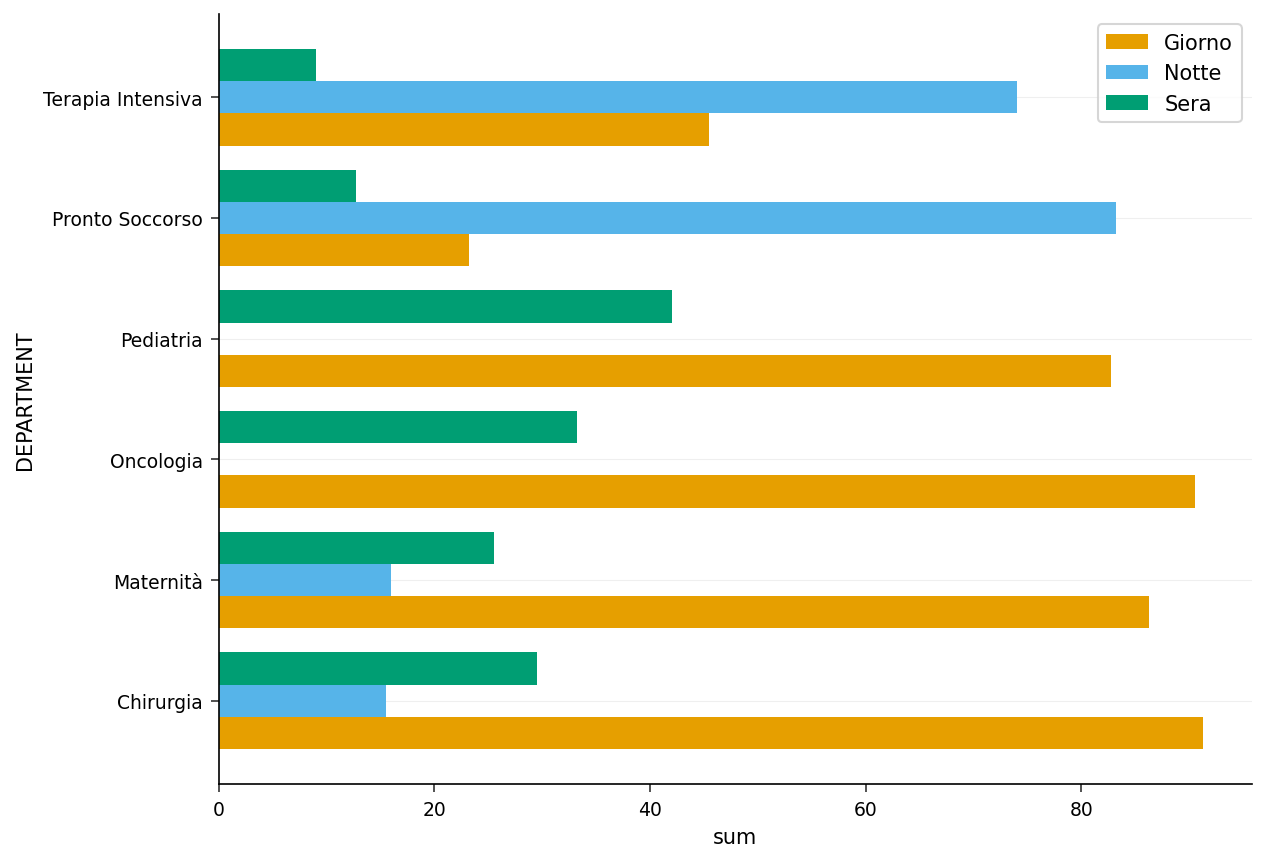

In [7]:
/* --------------------------------------------------------
   HBAR raggruppato per turno (GROUP=).
   Separa le ore di lavoro di Giorno / Sera / Notte all'interno
   di ogni reparto -- evidenziando le unita ad assistenza 24/7.
   -------------------------------------------------------- */
TITOLO 'Ore Lavorate per Reparto e Turno';
footnote JUSTIFY=LEFT
    'Le barre raggruppate separano i contributi di Giorno / Sera / Notte per reparto';

PROCEDURA GCHART DATI=work.staffing_log;
    HBAR department / GROUP=shift
                      SUMVAR=hours_worked
                      type=sum;
    ETICHETTA department='Reparto' shift='Turno' hours_worked='Ore Lavorate';
ESEGUIRE;
QUIT;

TITOLO; footnote;


NOTE: PROC GCHART data=work.staffing_log

NOTE: ODS plot written: gchart_hbar.spec.json


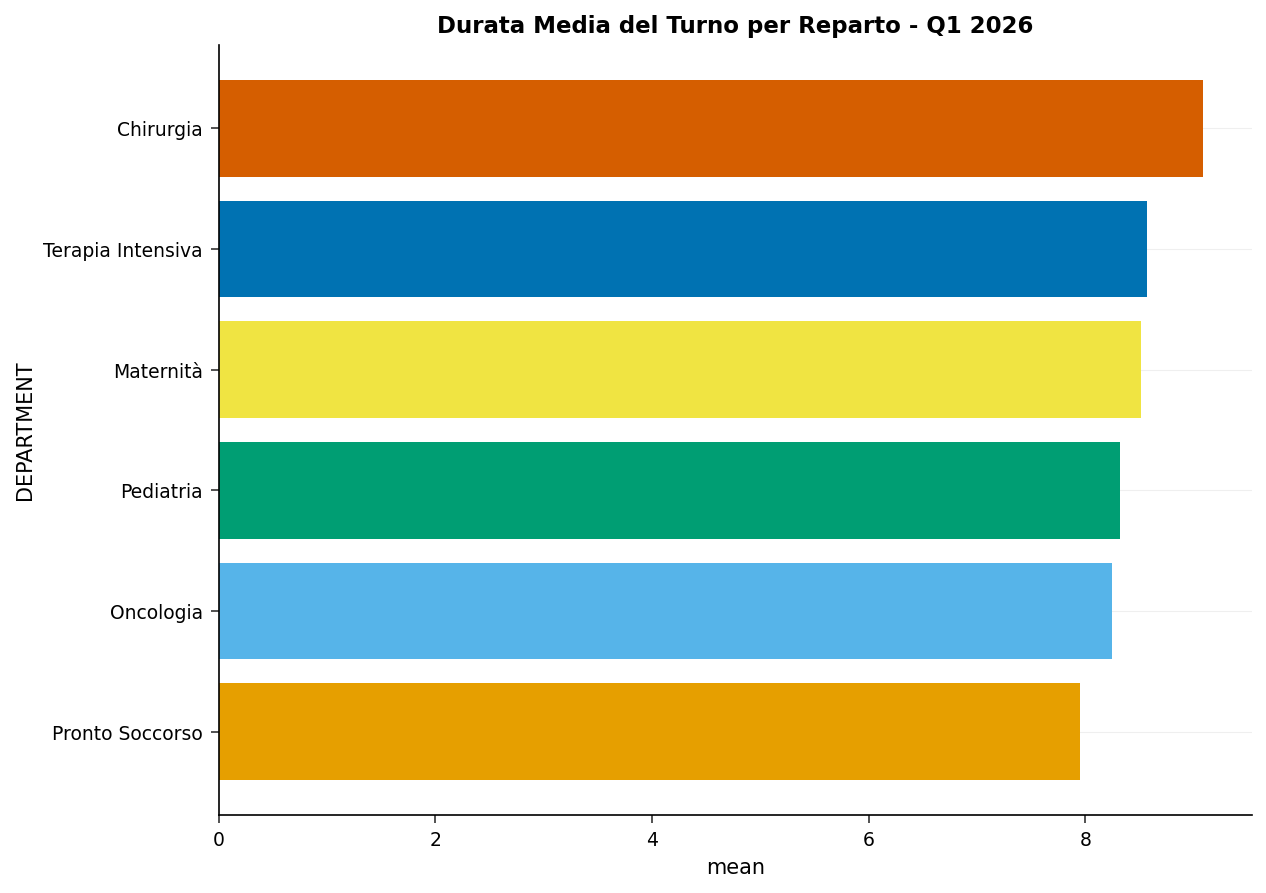

In [8]:
/* --------------------------------------------------------
   Durata media del turno per reparto (TYPE=MEAN).
   Rivela se un reparto fa turni lunghi o molti turni
   piu brevi, indipendentemente dal volume totale.
   -------------------------------------------------------- */
PROCEDURA GCHART DATI=work.staffing_log;
    HBAR department / SUMVAR=hours_worked
                      type=mean
                      DISCENDENTE;
    ETICHETTA department='Reparto' hours_worked='Ore Lavorate';
    TITOLO 'Durata Media del Turno per Reparto - Q1 2026';
ESEGUIRE;
QUIT;
TITOLO;

---

### Interpretazione

Sui 90 record turno, le ore totali di lavoro si mantengono in una banda stretta da **119.25** (Pronto Soccorso) a **136.25** (Chirurgia) perché ogni reparto ha lo stesso numero di 15 turni in questo periodo — quindi la classifica riflette la **durata del turno**, non il numero di turni. La Chirurgia è in testa sia al grafico delle ore totali sia al grafico del turno medio con **9.08 ore** per turno, coerentemente con i casi operatori più lunghi e la maggiore presenza di personale medico che questi casi richiedono. Il Pronto Soccorso si colloca in fondo per ore (media di **7.95**) nonostante sia una delle unità più impegnate, perché il suo lavoro si svolge in turni più brevi e con maggiore rotazione.

L'HBAR raggruppato per turno e il pannello a mosaico raccontano la storia operativamente rilevante. **Pronto Soccorso e Terapia Intensiva sono a prevalenza notturna** — rispettivamente 10 turni su 15 e 9 su 15 cadono di Notte — mentre **Oncologia e Pediatria non registrano alcun turno di Notte** e si concentrano sulla copertura di Giorno (11 e 10 turni di Giorno). Questa suddivisione rispecchia la reale organizzazione ospedaliera: le unità ad assistenza continua operano 24 ore su 24, mentre l'oncologia infusionale e la pediatria generale sono servizi diurni. Il pannello per categoria di risorsa conferma un **mix a guida infermieristica** in ogni reparto, con le ore di personale medico e sanitario ausiliario a formare i livelli secondari.

Per la revisione del personale del Q2, la concentrazione di turni notturni in Pronto Soccorso e Terapia Intensiva è la voce da monitorare: è lì che si accumulano i costi di maggiorazione notturna e di gestione dell'affaticamento, e dove qualsiasi modifica alla rotazione ha il maggiore impatto sul budget.

---

In [9]:
/* --------------------------------------------------------
   Esporta il riepilogo di reparto per il sistema
   di pianificazione del personale.
   -------------------------------------------------------- */
PROCEDURA EXPORT DATI=work.dept_summary
    OUTFILE='riepilogo_ore_lavoro_reparti_q1.csv'
    DBMS=csv REPLACE;
ESEGUIRE;


NOTE: PROC EXPORT data=work.dept_summary outfile=riepilogo_ore_lavoro_reparti_q1.csv

NOTE: Exported 6 rows to riepilogo_ore_lavoro_reparti_q1.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Riservato
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Con tecnologia <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>